# M5BAT evaluation month 04/2023

This notebook lists the released unit files, loads one battery unit at 1 s resolution for the month, and plots its SOC over one day. It makes no diagnosis.

## 1. Released units

This step lists what `systems('m5bat-2023-04')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('m5bat-2023-04')
display(released)

,unit,kind,abbreviation,technology,wiring,nominal_power_kw,nominal_energy_kwh,file,bytes,note
0,Batt1,battery unit,Pb1,lead-acid (OCSM),300s1p,630.0,1066.0,Batt1.csv,134713624,also released as m5bat-pbacid
1,Batt2,battery unit,Pb2,lead-acid (OCSM),300s1p,630.0,1066.0,Batt2.csv,135871500,
2,Batt3,battery unit,Pb3,lead-acid gel (OPzV),308s2p,630.0,843.0,Batt3.csv,133576941,
3,Batt4,battery unit,Pb4,lead-acid gel (OPzV),306s1p,522.0,740.0,Batt4.csv,132899224,
4,Batt5,battery unit,LMO1,lithium manganese oxide (LMO),192s16p,630.0,774.0,Batt5.csv,138149168,
5,Batt6,battery unit,LMO2,lithium manganese oxide (LMO),192s16p,630.0,774.0,Batt6.csv,138205956,
6,Batt7,battery unit,LMO3,lithium manganese oxide (LMO),192s16p,630.0,774.0,Batt7.csv,139015759,
7,Batt8,battery unit,LMO4,lithium manganese oxide (LMO),192s16p,630.0,774.0,Batt8.csv,138257235,
8,Batt9,battery unit,LFP,lithium iron phosphate (LFP),240s10p,630.0,738.0,Batt9.csv,138135865,
9,Batt10,battery unit,LTO,lithium titanate oxide (LTO),312s32p,630.0,230.0,Batt10.csv,143723301,


Each row is one CSV: ten battery units and BESS, the plant connection point. Batt1 is the lead-acid string also released as m5bat-pbacid. The report's p. 3 table gives each unit's technology: Batt1-2 OCSM lead-acid, Batt3-4 OPzV lead-acid gel, Batt5-8 LMO, Batt9 LFP, Batt10 LTO.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('m5bat-2023-04', unit='Batt2')
print(frame.shape)
display(frame.head())

(2592000, 13)


,P_AC_Set,Q_AC_Set,P_AC,Q_AC,SOC,I_DC_Batt,U_DC_Batt,Mode_PQ,Mode_Stop,Mode_Silent,Mode_Wait,interpolated,unit
DateAndTime,,,,,,,,,,,,,
2023-04-01 00:00:00+00:00,0,0,0,28,431,45,6255,0,0,1,0,0,Batt2
2023-04-01 00:00:01+00:00,42,0,0,28,431,4,6256,0,0,1,0,0,Batt2
2023-04-01 00:00:02+00:00,27,0,0,-13,431,4,6256,1,0,0,0,0,Batt2
2023-04-01 00:00:03+00:00,59,0,0,2,431,4,6256,1,0,0,0,0,Batt2
2023-04-01 00:00:04+00:00,88,0,59,-22,431,4,6256,1,0,0,0,0,Batt2


The unit has one row per second for all of April 2023. Values are integers as released. The evaluation report (pp. 6-7) gives their units: SOC in 0.1 %, I_DC_Batt in 0.1 A, U_DC_Batt in 0.1 V, power in kW and kVAr (negative = charging). The index is UTC (report pp. 6-7).

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['P_AC', 'SOC', 'I_DC_Batt', 'U_DC_Batt', 'interpolated']].describe().T)

,count,mean,std,min,25%,50%,75%,max
P_AC,2592000.0,-3.464724,67.633328,-452.0,0.0,0.0,0.0,451.0
SOC,2592000.0,542.867541,108.227913,0.0,462.0,524.0,600.0,1000.0
I_DC_Batt,2592000.0,-15.782269,1070.705365,-6633.0,4.0,4.0,4.0,8199.0
U_DC_Batt,2592000.0,6280.282051,178.188836,5597.0,6217.0,6256.0,6295.0,7171.0
interpolated,2592000.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

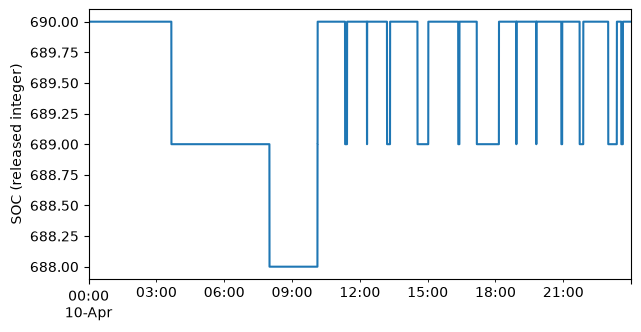

In [4]:
ax = frame.loc['2023-04-10', 'SOC'].plot(figsize=(7, 3.5))
ax.set_xlabel('')
ax.set_ylabel('SOC (released integer)')
plt.show()

Over one day the released SOC integer stays within a few units of 689, so the unit held a near-constant state of charge that day.